Mengekstraksi fitur linguistik, harap tunggu...
Melatih model Random Forest Baseline...

       HASIL EVALUASI METRIK BASELINE
   Metric  Score
 Accuracy 0.9121
Precision 0.9013
   Recall 0.9251
 F1-Score 0.9130


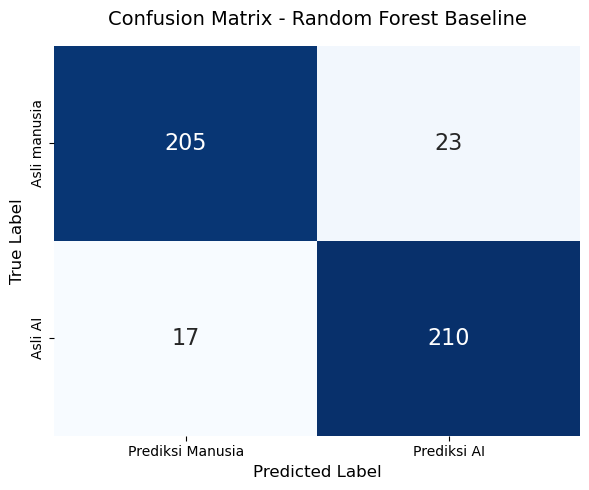


       FEATURE IMPORTANCES (RANKING)
  Linguistic Feature Importance Score
          word_count           0.2616
 std_sentence_length           0.2201
          koma_ratio           0.1707
       num_sentences           0.0932
 avg_sentence_length           0.0913
     func_word_ratio           0.0880
punct_kompleks_ratio           0.0751

       5-FOLD CROSS VALIDATION
Mean Accuracy : 0.9138
Std Deviation : 0.0099


In [3]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 1. Load dataset
df = pd.read_csv('../data/processed/final_dataset_detector_v1_12_fix.csv')

# 2. Ekstraksi 7 fitur linguistik
kata_fungsi = {
    'yang','dan','di','dengan','untuk','dari','pada','dalam','adalah',
    'ini','itu','ke','oleh','atau','juga','telah','akan','dapat',
    'sebagai','tidak','ada','sudah','serta','karena','namun','tetapi',
    'bahwa','sehingga','agar','ketika','jika','bila','maka','seperti'
}

def extract_features(text):
    text = str(text)
    words = text.split()
    words_lower = text.lower().split()
    sentences = [s.strip() for s in re.split(r'[.?!]', text) if len(s.strip().split()) >= 3]

    if not words:
        return {k: 0 for k in [
            'word_count','avg_sentence_length','std_sentence_length',
            'num_sentences','koma_ratio','punct_kompleks_ratio','func_word_ratio'
        ]}

    wc = len(words)
    sent_lens = [len(s.split()) for s in sentences]
    avg_sl = np.mean(sent_lens) if sent_lens else 0
    std_sl = np.std(sent_lens) if len(sent_lens) >= 2 else 0
    num_sent = len(sentences)
    koma_ratio = len(re.findall(r'[,]', text)) / wc
    punct_kompleks = len(re.findall(r'[;:()\[\]-]', text)) / wc
    func_word_ratio = sum(1 for w in words_lower if w in kata_fungsi) / wc

    return {
        'word_count': wc, 'avg_sentence_length': avg_sl,
        'std_sentence_length': std_sl, 'num_sentences': num_sent,
        'koma_ratio': koma_ratio, 'punct_kompleks_ratio': punct_kompleks,
        'func_word_ratio': func_word_ratio
    }

print("Mengekstraksi fitur linguistik, harap tunggu...")
feat_rows = df['abstract'].apply(extract_features).apply(pd.Series)
X = feat_rows.values
y = (df['label'] == 'ai').astype(int).values  # 1 = AI, 0 = Human
feature_names = feat_rows.columns.tolist()

# 3. Split 80/20 stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Train Random Forest
print("Melatih model Random Forest Baseline...")
clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# 5. Evaluasi (Format Tabel Rapi)
print("\n" + "="*40)
print("       HASIL EVALUASI METRIK BASELINE")
print("="*40)
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [
        f"{accuracy_score(y_test, y_pred):.4f}",
        f"{precision_score(y_test, y_pred):.4f}",
        f"{recall_score(y_test, y_pred):.4f}",
        f"{f1_score(y_test, y_pred):.4f}"
    ]
})
print(metrics_df.to_string(index=False))

# GENERATE GAMBAR CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Prediksi Manusia', 'Prediksi AI'], 
            yticklabels=['Asli manusia', 'Asli AI'], 
            annot_kws={"size": 16})

plt.title('Confusion Matrix - Random Forest Baseline', fontsize=14, pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

# 6. Feature importance 
print("\n" + "="*40)
print("       FEATURE IMPORTANCES (RANKING)")
print("="*40)
importances = sorted(zip(feature_names, clf.feature_importances_), key=lambda x: -x[1])
imp_df = pd.DataFrame(importances, columns=["Linguistic Feature", "Importance Score"])
imp_df["Importance Score"] = imp_df["Importance Score"].apply(lambda x: f"{x:.4f}")
print(imp_df.to_string(index=False))

# 7. Stabilitas: 5-fold CV
print("\n" + "="*40)
print("       5-FOLD CROSS VALIDATION")
print("="*40)
cv_scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy', n_jobs=-1)
print(f"Mean Accuracy : {cv_scores.mean():.4f}")
print(f"Std Deviation : {cv_scores.std():.4f}")
print("="*40)